Test Period: 2023-01-02 → 2025-12-31
 Improved RL model loaded

=== FINAL COMPARISON ===
         Metric  RL (Improved)  Rule-Based   NIFTY
0          CAGR        -0.0343     -0.0859  0.1337
1    Volatility         0.0612      0.1025  0.1201
2        Sharpe        -1.6035     -1.4593  0.5640
3  Max Drawdown        -0.1507     -0.3180 -0.1567


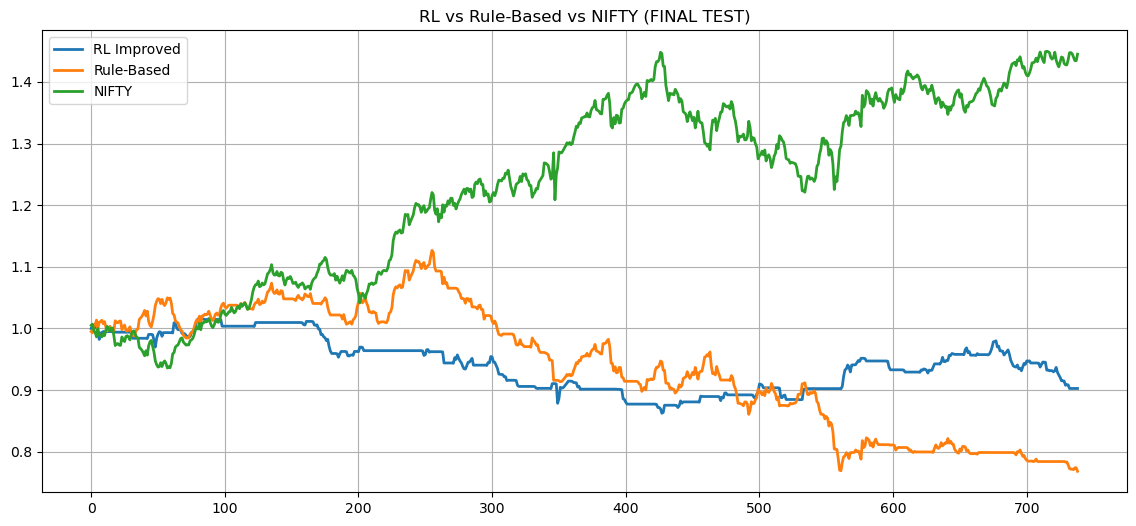


=== RL POSITION DISTRIBUTION ===
Long:  9.2%
Short: 23.2%
Flat:  67.6%


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. LOAD DATA (TEST PERIOD)
# =============================================
state_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
market_data = pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)

data = state_data.join(market_data[["nifty_ret"]], how="inner")
test_data = data.loc["2023":"2025"].copy()

print(f"Test Period: {test_data.index[0].date()} → {test_data.index[-1].date()}")

# =============================================
# 2. SAME ENVIRONMENT (MATCH DAY 40 EXACTLY)
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
    
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
    
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
    
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        
        net_ret = prev_position * ret - cost  # IMPORTANT
        
        self.balance *= (1 + net_ret)
        
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self._get_observation(), 0, done, {
            "net_ret": net_ret,
            "position": self.position
        }

# =============================================
# 3. DQN MODEL (MATCH DAY 40)
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    
    def forward(self, x):
        return self.net(x)

# =============================================
# 4. LOAD IMPROVED MODEL
# =============================================
policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/dqn_final_reward_optimized.pth", map_location=device))
policy_net.eval()

print(" Improved RL model loaded")

# =============================================
# 5. RUN RL AGENT
# =============================================
def run_rl(env, model):
    
    state = env.reset()
    done = False
    
    equity = 1.0
    equity_curve = [1.0]
    returns = []
    positions = []
    
    while not done:
        
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = model(s).argmax().item()
        
        next_state, _, done, info = env.step(action)
        
        net_ret = info["net_ret"]
        
        equity *= (1 + net_ret)
        
        equity_curve.append(equity)
        returns.append(net_ret)
        positions.append(info["position"])
        
        state = next_state
    
    return np.array(equity_curve), np.array(returns), np.array(positions)

env = QuantumAlphaEnv(test_data)
rl_equity, rl_returns, rl_positions = run_rl(env, policy_net)

# =============================================
# 6. RULE-BASED STRATEGY
# =============================================
rule = pd.read_csv("../backtesting/market_backtest_v7.csv", index_col=0)
rule.index = pd.to_datetime(rule.index)
rule = rule.loc["2023":"2025"]

rule_equity = (1 + rule["strategy_ret_v2"]).cumprod().values
rule_returns = rule["strategy_ret_v2"].values

# =============================================
# 7. NIFTY BENCHMARK
# =============================================
nifty_equity = (1 + test_data["nifty_ret"]).cumprod().values
nifty_returns = test_data["nifty_ret"].values

# =============================================
# 8. METRICS FUNCTION
# =============================================
def metrics(equity, returns):
    
    days = len(returns)
    
    cagr = equity[-1] ** (252 / days) - 1
    vol = np.std(returns) * np.sqrt(252)
    sharpe = (np.mean(returns) - 0.065/252) / (np.std(returns) + 1e-8) * np.sqrt(252)
    
    dd = equity / np.maximum.accumulate(equity) - 1
    max_dd = dd.min()
    
    return cagr, vol, sharpe, max_dd

rl_cagr, rl_vol, rl_sharpe, rl_dd = metrics(rl_equity, rl_returns)
rule_cagr, rule_vol, rule_sharpe, rule_dd = metrics(rule_equity, rule_returns)
nifty_cagr, nifty_vol, nifty_sharpe, nifty_dd = metrics(nifty_equity, nifty_returns)

# =============================================
# 9. FINAL COMPARISON TABLE
# =============================================
comparison = pd.DataFrame({
    "Metric": ["CAGR", "Volatility", "Sharpe", "Max Drawdown"],
    "RL (Improved)": [rl_cagr, rl_vol, rl_sharpe, rl_dd],
    "Rule-Based": [rule_cagr, rule_vol, rule_sharpe, rule_dd],
    "NIFTY": [nifty_cagr, nifty_vol, nifty_sharpe, nifty_dd]
})

print("\n=== FINAL COMPARISON ===")
print(comparison.round(4))

# =============================================
# 10. EQUITY CURVE
# =============================================
plt.figure(figsize=(14,6))

plt.plot(rl_equity, label="RL Improved", linewidth=2)
plt.plot(rule_equity[:len(rl_equity)], label="Rule-Based", linewidth=2)
plt.plot(nifty_equity[:len(rl_equity)], label="NIFTY", linewidth=2)

plt.title("RL vs Rule-Based vs NIFTY (FINAL TEST)")
plt.legend()
plt.grid(True)
plt.show()

# =============================================
# 11. POSITION ANALYSIS
# =============================================
print("\n=== RL POSITION DISTRIBUTION ===")
print(f"Long:  {(rl_positions == 1).mean():.1%}")
print(f"Short: {(rl_positions == -1).mean():.1%}")
print(f"Flat:  {(rl_positions == 0).mean():.1%}")